## 2. Exploratory Data Analysis & Visualization

This notebook builds on `01_data_cleaning.ipynb`. It keeps things simple:

- 4 clear charts, one plot each
- A short set of key statistics
- A plain-language takeaway after each section


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Libraries imported.")

Libraries imported.


## Load Cleaned Dataset

In [4]:
df = pd.read_csv("/content/cleaned_retail.csv", parse_dates=["InvoiceDate"])

print("Rows:", df.shape[0], "| Columns:", df.shape[1])
df.head()

Rows: 779425 | Columns: 10


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,PurchaseMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12


## Prepare a Few Extra Columns

We just need day of week, hour of day, and month for the charts below.

In [5]:
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour
df["PurchaseMonth"] = df["PurchaseMonth"].astype(str)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["DayOfWeek"] = pd.Categorical(df["DayOfWeek"], categories=day_order, ordered=True)

df[["InvoiceDate", "DayOfWeek", "Hour", "PurchaseMonth"]].head()

,InvoiceDate,DayOfWeek,Hour,PurchaseMonth
0,2009-12-01 07:45:00,Tuesday,7,2009-12
1,2009-12-01 07:45:00,Tuesday,7,2009-12
2,2009-12-01 07:45:00,Tuesday,7,2009-12
3,2009-12-01 07:45:00,Tuesday,7,2009-12
4,2009-12-01 07:45:00,Tuesday,7,2009-12


## Chart 1 — Monthly Revenue Trend

How revenue moves over time. Useful for spotting growth, decline, and seasonal spikes.

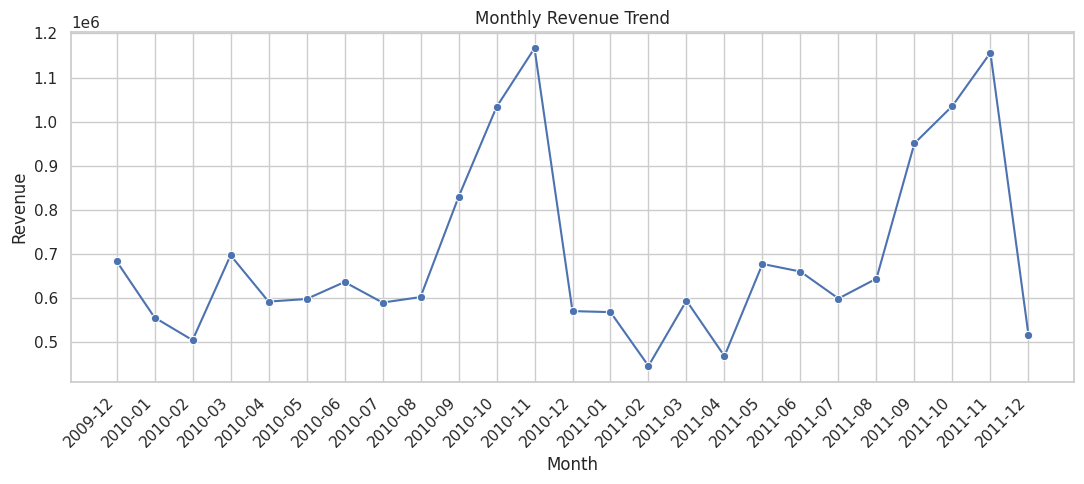

Highest revenue month: 2010-11 ($1,166,460)
Lowest revenue month:  2011-02 ($446,085)


In [6]:
monthly_revenue = df.groupby("PurchaseMonth")["Revenue"].sum().reset_index()

plt.figure(figsize=(11, 5))
sns.lineplot(data=monthly_revenue, x="PurchaseMonth", y="Revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

best_month = monthly_revenue.loc[monthly_revenue["Revenue"].idxmax()]
worst_month = monthly_revenue.loc[monthly_revenue["Revenue"].idxmin()]
print(f"Highest revenue month: {best_month['PurchaseMonth']} (${best_month['Revenue']:,.0f})")
print(f"Lowest revenue month:  {worst_month['PurchaseMonth']} (${worst_month['Revenue']:,.0f})")

## Chart 2 — Top 10 Countries by Revenue

Where the revenue comes from. The UK is excluded here since it's so much larger than
every other market that it hides the differences between the rest.

In [7]:
country_revenue = (
    df[df["Country"] != "United Kingdom"]
    .groupby("Country")["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Revenue", ascending=False)
    .head(10)
)

fig = px.bar(
    country_revenue,
    x="Revenue", y="Country",
    orientation="h",
    title="Top 10 Countries by Revenue (excl. UK)",
)
fig.update_yaxes(categoryorder="total ascending")
fig.show()

uk_share = df.loc[df["Country"] == "United Kingdom", "Revenue"].sum() / df["Revenue"].sum() * 100
print(f"United Kingdom alone makes up {uk_share:.1f}% of total revenue.")
print(f"Next biggest market: {country_revenue.iloc[0]['Country']}")

United Kingdom alone makes up 82.8% of total revenue.
Next biggest market: EIRE


## Chart 3 — When Do Customers Buy? (Day x Hour Heatmap)

Shows which days and hours see the most transactions — useful for staffing,
promotions, and marketing timing.

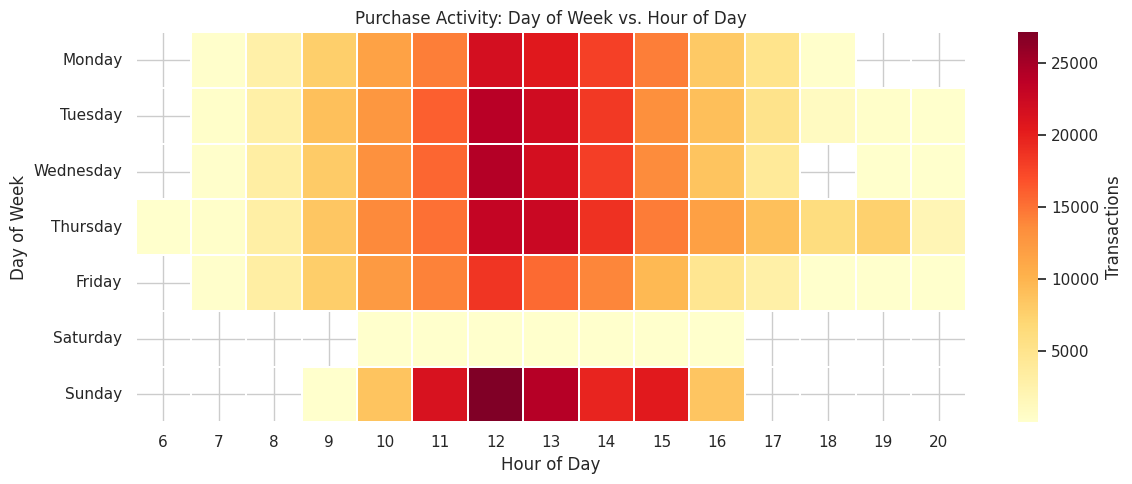

Busiest time: Sunday at 12:00


In [8]:
activity = (
    df.groupby(["DayOfWeek", "Hour"], observed=True)
    .size()
    .reset_index(name="Transactions")
    .pivot(index="DayOfWeek", columns="Hour", values="Transactions")
    .reindex(day_order)
)

plt.figure(figsize=(12, 5))
sns.heatmap(activity, cmap="YlOrRd", linewidths=0.3, cbar_kws={"label": "Transactions"})
plt.title("Purchase Activity: Day of Week vs. Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

peak_day, peak_hour = activity.stack().idxmax()
print(f"Busiest time: {peak_day} at {peak_hour}:00")

## Chart 4 — Customer Value (RFM) and How It Connects

Recency (days since last purchase), Frequency (number of orders), and Monetary
(total spend) are the three core measures of customer value. The heatmap shows
how strongly they relate to each other.

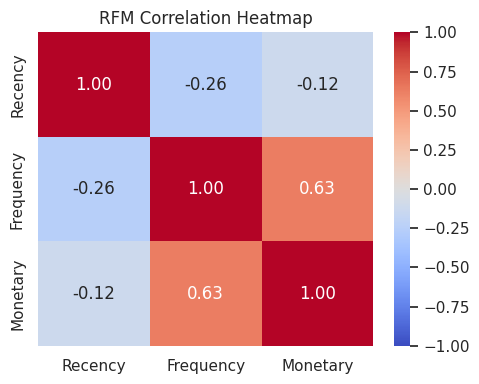

Correlation between Frequency and Monetary: 0.63
→ Customers who order more often also tend to spend more overall.


In [9]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum"),
).reset_index()

rfm_corr = rfm[["Recency", "Frequency", "Monetary"]].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(rfm_corr, cmap="coolwarm", annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("RFM Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Correlation between Frequency and Monetary:", round(rfm_corr.loc["Frequency", "Monetary"], 2))
print("→ Customers who order more often also tend to spend more overall.")

## Key Statistics

A quick summary of the numbers that matter most for understanding the business.

In [10]:
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
avg_order_value = total_revenue / total_orders

print(f"Total revenue:        ${total_revenue:,.0f}")
print(f"Total orders:         {total_orders:,}")
print(f"Total customers:      {total_customers:,}")
print(f"Average order value:  ${avg_order_value:,.2f}")

Total revenue:        $17,374,804
Total orders:         36,969
Total customers:      5,878
Average order value:  $469.98


In [11]:
# What share of revenue comes from the top 20% of customers?
rfm_sorted = rfm.sort_values("Monetary", ascending=False).reset_index(drop=True)
top20_cutoff = int(len(rfm_sorted) * 0.2)
top20_share = rfm_sorted.loc[:top20_cutoff - 1, "Monetary"].sum() / rfm_sorted["Monetary"].sum() * 100

print(f"Top 20% of customers generate {top20_share:.0f}% of total revenue.")
print("→ Revenue is concentrated in a small group of high-value, repeat customers.")

Top 20% of customers generate 77% of total revenue.
→ Revenue is concentrated in a small group of high-value, repeat customers.


## Summary

- **Revenue trend**: Sales peak and dip across the year — check Chart 1 for the exact
  months to plan around.
- **Markets**: The UK dominates overall sales; outside the UK, a handful of European
  countries make up most of the remaining revenue.
- **Timing**: Purchases cluster around specific weekdays and business hours (Chart 3) —
  useful for scheduling promotions or support.
- **Customer value**: Frequency and spend go hand in hand, and a small share of loyal
  customers drives most of the revenue — a strong case for retention efforts.
